### importing necessary libraries

In [1]:
#importing libraries
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import missingno as ms
import traceback
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

In [2]:
np.set_printoptions(precision = 4 , suppress = True)
pd.set_option("display.float_format" , "{:.4f}".format)

In [3]:
# importing packages installed
from scripts.data import data_ingestion
from src.data import data_validation
from src.data import data_cleaning
from src.utils.config import INTERIM,ROOT_DIR

Lahore Real Estate Price Prediction Pipeline


In [4]:
lohore_dataset = data_ingestion.read_data()

Filename: C:\Users\KISHORE\OneDrive\Desktop\Intelligent_Weather_Prediction_Pipeline\scripts\data\data_ingestion.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    90    236.0 MiB    236.0 MiB           1   @profile
    91                                         def read_data():
    92                                             """
    93                                             Reads the downloaded dataset file from dataset location.
    94                                         
    95                                             Args:
    96                                                 Nothing
    97                                         
    98                                             Returns:
    99                                                 Dataset(DataFrame): it contains Lahore House Listings from Zameen.com (2025).
   100                                             """
   101    246.1 MiB     10.1 MiB           1       dataset = pd.read_csv(RO

In [5]:
lohore_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                18249 non-null  object 
 1   Location             18249 non-null  object 
 2   Type                 18249 non-null  object 
 3   Price                18249 non-null  object 
 4   Area                 18249 non-null  object 
 5   Bedrooms             18249 non-null  object 
 6   Bathrooms            18249 non-null  object 
 7   Purpose              18249 non-null  object 
 8   Date Posted          11319 non-null  object 
 9   Built Year           13497 non-null  float64
 10  Kitchens             18249 non-null  int64  
 11  Store Rooms          18249 non-null  int64  
 12  Servant Quarters     18249 non-null  int64  
 13  Furnished            18249 non-null  bool   
 14  Gym                  18249 non-null  bool   
 15  Study Room           18249 non-null 

### Dataset Validation

In [6]:
data_validation.validate_dataset(lohore_dataset)

Schema data validation faild!


Traceback (most recent call last):
  File "C:\Users\KISHORE\OneDrive\Desktop\Intelligent_Weather_Prediction_Pipeline\Lahore_Real_Estate_Price_Prediction_Pipeline\src\data\data_validation.py", line 22, in validate_dataset
    schema.validate(data)
    ~~~~~~~~~~~~~~~^^^^^^
  File "C:\Users\KISHORE\anaconda3\envs\intern\Lib\site-packages\pandera\api\pandas\container.py", line 125, in validate
    return self._validate(
           ~~~~~~~~~~~~~~^
        check_obj=check_obj,
        ^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
        inplace=inplace,
        ^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\KISHORE\anaconda3\envs\intern\Lib\site-packages\pandera\api\pandas\container.py", line 145, in _validate
    return self.get_backend(check_obj).validate(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        check_obj,
        ^^^^^^^^^^
    ...<6 lines>...
        inplace=inplace,
        ^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\KISHORE\anaconda3\envs\intern\Lib\site-packages\pandera

'Dataset Validated Successfully.'

- **dataset have null records in Date Posted Column.**

In [7]:
lohore_dataset[lohore_dataset.duplicated()]

,Title,Location,Type,Price,Area,Bedrooms,Bathrooms,Purpose,Date Posted,Built Year,...,Furnished,Gym,Study Room,Drawing Room,Dining Room,Lawn/Garden,Swimming Pool,Electricity Backup,Lounge/Sitting Room,Link


In [8]:
lohore_dataset.isnull().sum()

Title                     0
Location                  0
Type                      0
Price                     0
Area                      0
Bedrooms                  0
Bathrooms                 0
Purpose                   0
Date Posted            6930
Built Year             4752
Kitchens                  0
Store Rooms               0
Servant Quarters          0
Furnished                 0
Gym                       0
Study Room                0
Drawing Room              0
Dining Room               0
Lawn/Garden               0
Swimming Pool             0
Electricity Backup        0
Lounge/Sitting Room       0
Link                      0
dtype: int64

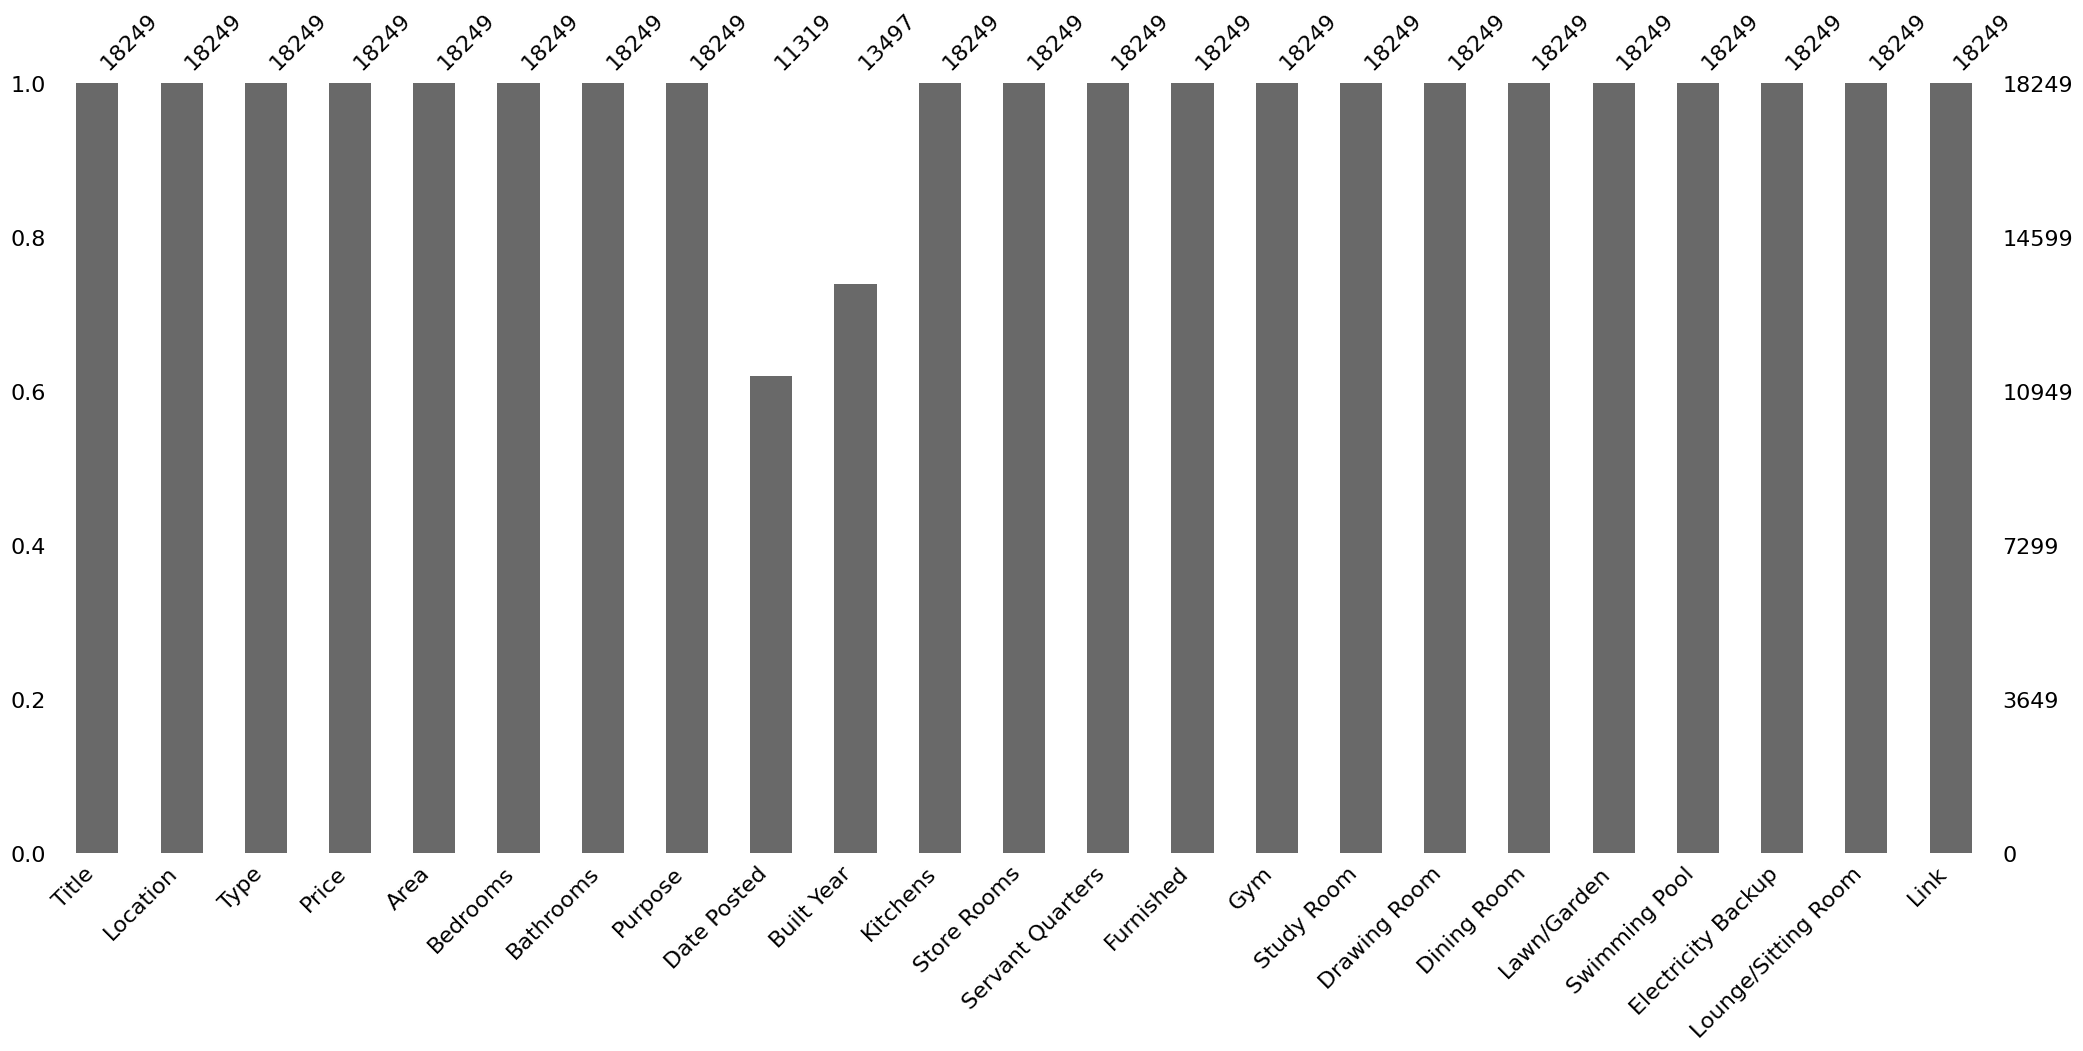

In [9]:
plt.figure(figsize = (1,1))
ms.bar(lohore_dataset)
plt.show()

In [10]:
null_perc = (lohore_dataset.isnull().sum() / len(lohore_dataset))*100

In [11]:
null_cols = null_perc[null_perc > 0].index.tolist()
null_cols

['Date Posted', 'Built Year']

### Cleaning Dataset

In [12]:
cleaner = data_cleaning.clean_dataset(lohore_dataset,null_cols)

In [13]:
lohore_dataset = cleaner.handle_null_records()

In [14]:
lohore_dataset["Area_sqft"] = lohore_dataset["Area"].apply(cleaner.convert_to_sqft).astype(float)

In [15]:
lohore_dataset["Price_PKR"] = lohore_dataset["Price"].apply(cleaner.convert_price).astype(float)

In [16]:
lohore_dataset = cleaner.rename_columns()

In [17]:
cols = ["Bedrooms", "Bathrooms"]
clean_lohore_dataset = cleaner.remove_data_inconsistency(cols)

In [18]:
clean_lohore_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                18249 non-null  object 
 1   Location             18249 non-null  object 
 2   Type                 18249 non-null  object 
 3   Price                18249 non-null  object 
 4   Area                 18249 non-null  object 
 5   Bedrooms             17931 non-null  float64
 6   Bathrooms            17829 non-null  float64
 7   Purpose              18249 non-null  object 
 8   Kitchens             18249 non-null  int64  
 9   Store_Rooms          18249 non-null  int64  
 10  Servant_Quarters     18249 non-null  int64  
 11  Furnished            18249 non-null  bool   
 12  Gym                  18249 non-null  bool   
 13  Study_Room           18249 non-null  bool   
 14  Drawing_Room         18249 non-null  bool   
 15  Dining_Room          18249 non-null 

In [19]:
clean_lohore_dataset.dropna(inplace = True)

In [20]:
print("Memory Usage of the dataset is : ", clean_lohore_dataset.memory_usage(),end = "\n")

Memory Usage of the dataset is :  Index                  142464
Title                  142464
Location               142464
Type                   142464
Price                  142464
Area                   142464
Bedrooms               142464
Bathrooms              142464
Purpose                142464
Kitchens               142464
Store_Rooms            142464
Servant_Quarters       142464
Furnished               17808
Gym                     17808
Study_Room              17808
Drawing_Room            17808
Dining_Room             17808
Lawn_Garden             17808
Swimming_Pool           17808
Electricity_Backup      17808
Lounge_Sitting_Room     17808
Link                   142464
Area_sqft              142464
Price_PKR              142464
dtype: int64


### Saving cleaned dataset

In [21]:
#ROOT_DIR = Path.cwd().parent
os.chdir(ROOT_DIR/INTERIM)
clean_lohore_dataset.to_csv("clean_lohore_dataset.csv",index = False)
print("file Saved Successfully!")

file Saved Successfully!
